In [1]:
# ================================================================================
# BLOQUE 1: IMPORTACIONES Y CONFIGURACIÓN
# ================================================================================
import pandas as pd
import numpy as np
import warnings
from scipy.stats.mstats import winsorize
from scipy.stats import spearmanr
from sklearn.model_selection import KFold, GroupKFold # Añadido GroupKFold para el Bloque 6
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib
import matplotlib.pyplot as plt

# !! AJUSTE: AÑADIR ESTAS LIBRERÍAS ESTÁNDAR !!
import os
import requests
import time

# Ignorar warnings para una salida más limpia
warnings.filterwarnings('ignore')
pd.options.mode.chained_assignment = None

# --- Configuración del Experimento ---
TARGET_HORIZON = 1
VALUATION_MOMENTUM_WINDOW = 6
MIN_PERIODS_WINDOW = 3
CV_FOLDS = 5

# --- AJUSTE: Definir la fecha de corte para el split temporal ---
FINAL_EVAL_SPLIT_DATE = '2022-12-31'

# --- Configuración de la API Finnhub ---
FINNHUB_API_KEY = "d1laggpr01qt4thevnq0d1laggpr01qt4thevnqg"  # <-- IMPORTANTE: pon aquí tu clave de Finnhub
CACHE_FILE      = "finnhub_sector_industry.pkl" # Cache local para no repetir descargas
RATE_LIMIT      = 60  # Límite de llamadas por minuto para el plan gratuito de Finnhub
SLEEP_SECONDS   = 61  # Pausa tras RATE_LIMIT llamadas (un segundo extra por seguridad)

Esa es una pregunta excelente y muy importante. La elección de la fecha de corte (`FINAL_EVAL_SPLIT_DATE = '2022-12-31'`) no es aleatoria y se basa en un equilibrio entre varios factores clave en el diseño de un backtest.

No hay una única respuesta "correcta", pero la elección de `2022-12-31` es una decisión muy razonable y defendible por las siguientes razones:

### 1. Asegurar un Período de Prueba "Out-of-Time" Suficientemente Largo

*   **Objetivo:** Necesitas un período de prueba (test set) que sea lo suficientemente largo como para no ser una simple casualidad. Un solo mes de prueba no te dice nada. Un año o más es mucho más robusto.
*   **Con este corte:**
    *   **Train/Validation Set:** Desde Octubre 2014 hasta Diciembre 2022 (~8 años de datos).
    *   **Test Set:** Desde Enero 2023 hasta Septiembre 2024 (~1.75 años de datos).
*   **Por qué es bueno:** Un período de prueba de casi dos años es lo suficientemente largo como para incluir diferentes condiciones de mercado (por ejemplo, la subida de tipos de interés de 2023) y darte una idea más fiable de cómo se comportaría el modelo en el futuro.

### 2. Mantener un Conjunto de Entrenamiento Robusto

*   **Objetivo:** El modelo necesita ver suficientes datos y regímenes de mercado para aprender patrones generalizables. Si haces el corte demasiado pronto (ej. en 2018), el modelo no aprenderá de los eventos más recientes como la pandemia o la inflación post-pandemia.
*   **Con este corte:**
    *   El conjunto de entrenamiento de ~8 años es muy sólido. Incluye períodos de baja volatilidad, la crisis del COVID-19, y el inicio del ciclo de subida de tipos. Esto le da al modelo una rica variedad de escenarios para aprender.

### 3. La Regla del 80/20 (Aproximada)

*   **Objetivo:** Una práctica común en Machine Learning es usar aproximadamente el 70-80% de los datos para entrenar y el 20-30% para probar.
*   **Con este corte:**
    *   Tu período total de datos es de 10 años (Oct 2014 - Sep 2024).
    *   El entrenamiento cubre ~8.2 años (~82%).
    *   La prueba cubre ~1.8 años (~18%).
*   **Por qué es bueno:** Se alinea bien con las heurísticas estándar, asegurando un buen equilibrio entre la cantidad de datos para aprender y la cantidad de datos para una evaluación robusta.

### 4. Evitar el "Recency Bias" en la Evaluación

*   **Objetivo:** La prueba más dura para un modelo es predecir el futuro más reciente, ya que las condiciones del mercado cambian constantemente.
*   **Con este corte:**
    *   Estás probando el modelo en el período más reciente y, por lo tanto, más relevante (2023-2024). Si el modelo funciona bien aquí, te da más confianza en su rendimiento futuro que si solo lo hubieras probado en, por ejemplo, 2019.

### Alternativas y Cuándo Podrías Cambiarla

*   **Si tuvieras 30 años de datos:** Podrías usar un período de prueba más largo, como 5 años, y seguir teniendo 25 años para entrenar.
*   **Si quisieras probar la robustez en una crisis específica:** Podrías hacer un corte justo antes de la pandemia (`2019-12-31`) para ver específicamente cómo se comportó tu modelo durante el caos de 2020.
*   **Walk-Forward Validation (Más Avanzado):** En lugar de un único split, podrías hacer varios. Entrenar hasta 2020 y probar en 2021. Luego, entrenar hasta 2021 y probar en 2022, y así sucesivamente. Esto da una medida aún más robusta del rendimiento a lo largo del tiempo.

**En resumen:** La fecha `2022-12-31` fue elegida como un **punto de equilibrio pragmático y defendible** que te da un conjunto de entrenamiento grande y variado, y un conjunto de prueba reciente y lo suficientemente largo como para que los resultados sean significativos. Es una elección estándar y sólida para un proyecto de estas características.

In [2]:
# ================================================================================
# BLOQUE 2: CARGA, LIMPIEZA INICIAL Y ENRIQUECIMIENTO CON DATOS DE SECTOR
# ================================================================================
# --- 2.1: Carga y Limpieza Inicial ---
# Cargar los datos (reemplaza con tu ruta de archivo)
file_path = 'C:/Users/Andy/OneDrive/Desktop/MCD/Tesis/Datos_fuente_Bloomberg/en valores/serie completa 2014-2024/Dataset/dataset_oct_2014-set_2024_sin dlocal.xlsx'
df = pd.read_excel(file_path, sheet_name='dataset')

# Limpieza y Conversión de Tipos
df['Non farm payrolls_Exp_mediana'] = df['Non farm payrolls_Exp_mediana'].astype(str).str.replace('k', '').astype(float)
df['Non farm payrolls_Exp_promedio'] = df['Non farm payrolls_Exp_promedio'].astype(str).str.replace('k', '').astype(float)
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%Y%m%d')
df['CPI'] /= 100
df['Fed Funds Rate'] /= 100

# Ordenar datos, es crucial para cálculos temporales
df = df.sort_values(['Empresa', 'Fecha']).reset_index(drop=True)
print("Datos cargados y limpieza inicial completada.")

# --- 2.2: Descarga y Unión de Datos de Sector desde Finnhub ---
print("\nIniciando descarga de datos de sector desde Finnhub...")

# Función de limpieza para convertir ticker de Bloomberg a formato estándar
def bloomberg_to_symbol(tk:str) -> str:
    return tk.split()[0].replace('.', '-')

symbols_to_fetch = df['Empresa'].map(bloomberg_to_symbol).unique().tolist()

# Cargar caché si existe
if os.path.exists(CACHE_FILE):
    sector_df = pd.read_pickle(CACHE_FILE)
    cached_symbols = set(sector_df['Symbol'])
else:
    sector_df = pd.DataFrame()
    cached_symbols = set()

records_to_add = []
tickers_to_process = [s for s in symbols_to_fetch if s not in cached_symbols]

if not tickers_to_process:
    print("  - Todos los datos de sector ya estaban en el caché.")
else:
    print(f"  - Se descargarán datos para {len(tickers_to_process)} nuevos tickers.")
    for i, symbol in enumerate(tickers_to_process, 1):
        print(f"    Descargando {symbol} ({i}/{len(tickers_to_process)})...")
        url = f"https://finnhub.io/api/v1/stock/profile2?symbol={symbol}&token={FINNHUB_API_KEY}"
        
        try:
            response = requests.get(url, timeout=15)
            response.raise_for_status()  # Lanza un error para códigos 4xx/5xx
            data = response.json()

            if data and data.get('finnhubIndustry'):
                records_to_add.append({
                    'Symbol':   symbol,
                    'Sector':   data.get('gicSector') or data.get('finnhubIndustry'), # Prioriza GICS
                    'Industry': data.get('finnhubIndustry')
                })
            else:
                print(f"    ⚠️  Sin datos de sector para {symbol}.")
        except requests.exceptions.RequestException as e:
            print(f"    ❌ Error de red para {symbol}: {e}")
        
        # Respetar el límite de tasa de la API
        if i % RATE_LIMIT == 0 and i < len(tickers_to_process):
            print(f"  - Límite de {RATE_LIMIT} llamadas alcanzado. Pausando por {SLEEP_SECONDS} segundos...")
            time.sleep(SLEEP_SECONDS)

    # Añadir los nuevos registros y guardar el caché actualizado
    if records_to_add:
        new_data_df = pd.DataFrame(records_to_add)
        sector_df = pd.concat([sector_df, new_data_df], ignore_index=True).drop_duplicates('Symbol')
        sector_df.to_pickle(CACHE_FILE)
        print(f"\n{len(records_to_add)} nuevos símbolos añadidos al caché -> {CACHE_FILE}")

# Unir los datos de sector al DataFrame principal
if not sector_df.empty:
    df['Symbol_key'] = df['Empresa'].map(bloomberg_to_symbol)
    df = pd.merge(
        df,
        sector_df,
        left_on='Symbol_key',
        right_on='Symbol',
        how='left'
    )
    df.drop(columns=['Symbol_key', 'Symbol'], inplace=True)
    print("\nDatos de Sector e Industria unidos al DataFrame principal.")
else:
    print("\nNo se pudieron obtener datos de sector.")

Datos cargados y limpieza inicial completada.

Iniciando descarga de datos de sector desde Finnhub...
  - Todos los datos de sector ya estaban en el caché.

Datos de Sector e Industria unidos al DataFrame principal.


In [3]:
# --- 2.3: Conteo de Empresas por Sector ---
sector_counts = df['Sector'].value_counts().reset_index()
sector_counts

,index,Sector
0,Technology,2160
1,Retail,2040
2,Semiconductors,2040
3,Electrical Equipment,1440
4,Health Care,1200
5,Financial Services,1200
6,Food Products,840
7,Professional Services,840
8,Commercial Services & Supplies,720
9,Trading Companies & Distributors,720


In [4]:
# --- 2.4: Conteo de Empresas por Industria ---
industry_counts = df['Industry'].value_counts().reset_index()
industry_counts

,index,Industry
0,Technology,2160
1,Retail,2040
2,Semiconductors,2040
3,Electrical Equipment,1440
4,Health Care,1200
5,Financial Services,1200
6,Food Products,840
7,Professional Services,840
8,Commercial Services & Supplies,720
9,Trading Companies & Distributors,720


Sí, es **muy posible y bastante común** que los valores de `Sector` e `Industry` sean iguales, especialmente dependiendo de la fuente de datos y el nivel de granularidad de su sistema de clasificación.

Analicemos por qué ocurre esto y cómo manejarlo.

### ¿Por qué `Sector` e `Industry` pueden ser iguales?

1.  **Sistemas de Clasificación Jerárquicos (Como GICS):**
    *   El estándar más común es el GICS (Global Industry Classification Standard). Este sistema es una jerarquía de 4 niveles:
        1.  **Sector:** El nivel más alto (ej. "Information Technology", "Health Care", "Financials"). Hay 11 sectores en total.
        2.  **Industry Group:** Un subconjunto del sector (ej. dentro de "Information Technology", está "Software & Services").
        3.  **Industry:** Un nivel más específico (ej. dentro de "Software & Services", está "Software").
        4.  **Sub-Industry:** El nivel más granular (ej. dentro de "Software", está "Application Software").
    *   **El problema:** Muchas APIs, para simplificar, solo proporcionan uno o dos de estos niveles. Es muy común que una API devuelva el **Industry Group** o la **Industry** y lo etiquete tanto como "Sector" como "Industry" en su respuesta, especialmente si no ofrecen la jerarquía completa.

2.  **Clasificaciones Propietarias de la API:**
    *   Algunas APIs (como Finnhub con su `finnhubIndustry`) usan su propio sistema de clasificación. Este sistema puede no ser tan profundo como el GICS y podría tener solo un nivel significativo. En ese caso, es lógico que devuelvan el mismo valor para ambos campos.

3.  **Caso de tu Código con Finnhub:**
    *   Tu lógica es: `'Sector': js.get('gicSector') or js.get('finnhubIndustry')`.
    *   Esto significa que si `gicSector` (el nivel más alto de GICS) no está disponible, el campo `Sector` en tu DataFrame tomará el valor de `finnhubIndustry`.
    *   Al mismo tiempo, el campo `Industry` en tu DataFrame *siempre* toma el valor de `finnhubIndustry`.
    *   Por lo tanto, **en todos los casos en que `gicSector` falte, `Sector` e `Industry` serán idénticos en tu DataFrame por diseño.** Esto es una buena práctica de fallback, no un error.

### ¿Qué Hacer al Respecto?

No es un problema grave, pero tienes varias opciones para manejarlo de forma limpia.

#### Opción 1: Ignorarlo (La más simple)

*   **Lógica:** Si son iguales, no pasa nada. Simplemente tendrás dos columnas con la misma información. Cuando crees los dummies para `Sector`, el modelo usará esa información. La columna `Industry` quedará sin usar o puedes optar por no incluirla en tus predictores.
*   **Ventaja:** No requiere cambios en el código.

#### Opción 2: Usar solo una de las Columnas

*   **Lógica:** Dado que `Sector` ya contiene la mejor información disponible (priorizando GICS), puedes simplemente ignorar la columna `Industry` en el resto de tu análisis.
*   **Implementación:** Cuando definas tu lista de `predictor_cols_base`, simplemente no incluyas `Industry` (o los dummies de `Industry`).

#### Opción 3: Crear una Jerarquía si es Posible (La más avanzada)

*   **Lógica:** Puedes crear una lógica que solo use `Industry` si es diferente de `Sector`, para capturar un nivel de granularidad adicional cuando esté disponible.
*   **Implementación:**
    1.  Después de unir los datos, crea una nueva columna `Industry_granular`.
    2.  Si `Industry` es diferente de `Sector`, `Industry_granular` toma el valor de `Industry`. Si no, se queda como `NaN` o un valor como "Mismo que Sector".
    3.  Luego puedes crear dummies solo para `Industry_granular`.

    ```python
    # Ejemplo de implementación de la Opción 3
    if 'Sector' in df.columns and 'Industry' in df.columns:
        df['Industry_granular'] = df['Industry'].where(df['Industry'] != df['Sector'], 'Mismo_que_Sector')
        
        # Crear dummies para la nueva columna, excluyendo el valor de relleno
        industry_dummies = pd.get_dummies(df['Industry_granular'], prefix='industry', drop_first=True)
        # Eliminar la columna que no queremos (la que indica que es lo mismo)
        if 'industry_Mismo_que_Sector' in industry_dummies.columns:
            industry_dummies.drop(columns=['industry_Mismo_que_Sector'], inplace=True)
            
        df = pd.concat([df, industry_dummies], axis=1)
    ```

### Recomendación

**Empieza con la Opción 2 (Usar solo `Sector`).**

Es la más limpia y directa. Tu lógica de `js.get('gicSector') or js.get('finnhubIndustry')` ya garantiza que la columna `Sector` contenga la mejor información de clasificación disponible. Crea los dummies solo para esta columna e inclúyelos en tu modelo.

Esto evita la redundancia y te permite controlar por el efecto de la clasificación industrial de la manera más robusta y sencilla posible. Si más adelante descubres que necesitas más granularidad, puedes explorar la Opción 3.

In [5]:
# ================================================================================
# BLOQUE 3: FEATURE ENGINEERING AVANZADO (VERSIÓN FINAL Y ROBUSTA)
# ================================================================================
print("\nIniciando Feature Engineering...")

# --- 3.1 y 3.2 (Sin cambios) ---
# ... (tu código para features base y momentum de valoración va aquí) ...
for p in [1, 3, 6, 12]:
    df[f'ret_P_Share_{p}m_base'] = df.groupby('Empresa')['P_Share'].transform(lambda x: x.pct_change(periods=p))
for w in [3, 6, 12]:
    df[f'vol_P_Share_{w}m_base'] = df.groupby('Empresa')['P_Share'].transform(lambda x: x.rolling(window=w, min_periods=MIN_PERIODS_WINDOW).std())
df['dif_CPI_mediana'] = (df['CPI'] - df['CPI_Exp_mediana']) * 10000
df['dif_FFR_mediana'] = (df['Fed Funds Rate'] - df['Fed Funds Rate_Exp_mediana']) * 10000
df['dif_NFP_mediana'] = df['Non farm payrolls'] - df['Non farm payrolls_Exp_mediana']
base_feature_cols = [col for col in df.columns if '_base' in col or 'dif_' in col]
for col in base_feature_cols:
    df[col].fillna(0, inplace=True)
print("  - Features base (momentum, volatilidad, macro) creadas.")

df['P_E_winsorized'] = df.groupby('Empresa')['P_E'].transform(lambda x: winsorize(x, limits=[0.01, 0.01])).astype(float)
eps = 1e-6
rolling_median = df.groupby('Empresa')['P_E_winsorized'].transform(lambda x: x.rolling(VALUATION_MOMENTUM_WINDOW, min_periods=MIN_PERIODS_WINDOW).median())
rolling_mad = df.groupby('Empresa')['P_E_winsorized'].transform(lambda x: x.rolling(VALUATION_MOMENTUM_WINDOW, min_periods=MIN_PERIODS_WINDOW).apply(lambda s: np.median(np.abs(s - np.median(s))) + eps, raw=False))
df['PE_zscore_6m'] = (df['P_E_winsorized'] - rolling_median) / (rolling_mad * 1.4826)
df['PE_zscore_6m'].replace([np.inf, -np.inf], 0, inplace=True)
df['PE_zscore_6m'].fillna(0, inplace=True)
df['is_short_hist_zscore'] = (df.groupby('Empresa').cumcount() < VALUATION_MOMENTUM_WINDOW).astype(int)
df.drop(columns=['P_E_winsorized'], inplace=True)
print("  - Feature de Momentum de Valoración creada.")


# --- 3.3: Creación de Dummies Sectoriales (IDEMPOTENTE) ---
if 'Sector' in df.columns:
    # !! AJUSTE CLAVE: Eliminar columnas de dummies viejas antes de crear nuevas !!
    cols_to_drop = [col for col in df.columns if str(col).startswith('sector_')]
    if cols_to_drop:
        df.drop(columns=cols_to_drop, inplace=True)
        print(f"  - Se eliminaron {len(cols_to_drop)} columnas de dummies de sector preexistentes.")

    df['Sector'].fillna('Unknown', inplace=True)
    sector_dummies = pd.get_dummies(df['Sector'], prefix='sector', drop_first=True)
    df = pd.concat([df, sector_dummies], axis=1)
    print(f"  - {len(sector_dummies.columns)} dummies sectoriales creados y unidos.")
else:
    print("  - ADVERTENCIA: No se encontró la columna 'Sector', no se crearon dummies.")

# --- 3.4: Creación de Dummy de Régimen de Pandemia ---
# (Sin cambios)
PANDEMIC_START = '2020-03-01'
PANDEMIC_END = '2021-06-30'
df['pandemic_dummy'] = (
    (df['Fecha'] >= PANDEMIC_START) & 
    (df['Fecha'] <= PANDEMIC_END)
).astype(int)
print(f"  - Dummy de régimen de pandemia creada.")

print("\n--- Fin del Bloque 3. DataFrame listo para el manejo de lags. ---")


Iniciando Feature Engineering...
  - Features base (momentum, volatilidad, macro) creadas.
  - Feature de Momentum de Valoración creada.
  - 33 dummies sectoriales creados y unidos.
  - Dummy de régimen de pandemia creada.

--- Fin del Bloque 3. DataFrame listo para el manejo de lags. ---


In [6]:
# ================================================================================
# BLOQUE 4: MANEJO PRECISO DE LAGS CONTABLES Y CREACIÓN DEL TARGET
# ================================================================================
print("\nAplicando lag de publicación preciso y creando el target...")

# --- 4.1: Identificar tipos de features ---
# (Estas listas se usan para seleccionar las columnas correctas en los siguientes pasos)
features_mercado = ['P_E', 'P_B', 'P_S', 'ret_P_Share_1m_base', 'ret_P_Share_3m_base', 'ret_P_Share_6m_base', 'ret_P_Share_12m_base', 'vol_P_Share_3m_base', 'vol_P_Share_6m_base', 'vol_P_Share_12m_base', 'PE_zscore_6m', 'is_short_hist_zscore']
features_contables = ['ROCE_l', 'ROA_l', 'EBIT_l', 'Total Activos_l', 'Deuda a LP_l', 'Beneficio neto_l', 'ROI_l', 'EV_l', 'Cap de mercado_l', 'Deuda a CP_l', 'Efectivo y equiv_l']
features_macro = ['dif_CPI_mediana', 'dif_FFR_mediana', 'dif_NFP_mediana']
# Añadir los dummies de sector a la lista de features de mercado, ya que se conocen en tiempo real
sector_dummy_cols = [col for col in df.columns if col.startswith('sector_')]
features_mercado.extend(sector_dummy_cols)


# --- 4.2: Anclaje Trimestral usando Periodos de Pandas ---
# Este es el método más robusto y eficiente para implementar tu regla de negocio.

# a) Crear un DataFrame solo con los datos contables en las fechas de fin de trimestre
df_contable_q = df.loc[df['Fecha'].dt.is_quarter_end].copy()
# Crear la clave de unión: el Periodo Trimestral (ej. '2022Q1')
df_contable_q['periodo_trimestre'] = df_contable_q['Fecha'].dt.to_period('Q')

# b) Para cada fila del DataFrame principal, calcular a qué informe trimestral corresponde
# Convertimos la fecha mensual a un periodo trimestral y le restamos 2 trimestres.
# Esto simula el lag de publicación de ~3-6 meses.
QUARTERLY_OFFSET = 2
df['periodo_informe'] = (df['Fecha'].dt.to_period('Q') - QUARTERLY_OFFSET)

# c) Unir los datos contables correctos usando la clave de Periodo
# Primero, eliminamos las columnas contables originales para evitar conflictos
df.drop(columns=features_contables, inplace=True, errors='ignore')

df = pd.merge(
    df,
    df_contable_q[['Empresa', 'periodo_trimestre'] + features_contables],
    left_on=['Empresa', 'periodo_informe'],
    right_on=['Empresa', 'periodo_trimestre'],
    how='left'
)

# Limpiar las columnas auxiliares de periodos
df.drop(columns=['periodo_informe', 'periodo_trimestre'], inplace=True, errors='ignore')
print("  - Lag de publicación contable aplicado con anclaje de Periodos.")

# --- 4.3: Crear la variable objetivo (Target) ---
TARGET_COL = f'retorno_futuro_{TARGET_HORIZON}m'
df[TARGET_COL] = df.groupby('Empresa')['P_Share'].shift(-TARGET_HORIZON) / df['P_Share'] - 1

# Eliminar las filas donde no se puede calcular el retorno futuro (las últimas de cada empresa)
rows_before = len(df)
df.dropna(subset=[TARGET_COL], inplace=True)
print(f"  - Se eliminaron {rows_before - len(df)} filas sin target futuro.")

print("\n--- Fin del Bloque 4. DataFrame con target y lags de publicación listos. ---")


Aplicando lag de publicación preciso y creando el target...
  - Lag de publicación contable aplicado con anclaje de Periodos.
  - Se eliminaron 180 filas sin target futuro.

--- Fin del Bloque 4. DataFrame con target y lags de publicación listos. ---


In [7]:
# ================================================================================
# BLOQUE 5: PREPARACIÓN FINAL DEL DATASET
# ================================================================================
print("\nPreparando el dataset final para el modelado...")
print("  HIPÓTESIS ACTUAL: Se usará un lag universal de 1 mes para todas las features.")

# --- 5.1: Definir la lista completa de predictores base ---
# (Misma lógica que antes, pero seremos extra cuidadosos)

sector_dummy_cols = [col for col in df.columns if str(col).startswith('sector_')]
features_mercado = [
    'P_E', 'P_B', 'P_S', 'ret_P_Share_1m_base', 'ret_P_Share_3m_base', 'ret_P_Share_6m_base', 'ret_P_Share_12m_base', 
    'vol_P_Share_3m_base', 'vol_P_Share_6m_base', 'vol_P_Share_12m_base', 'PE_zscore_6m', 'is_short_hist_zscore'
]
features_mercado.extend(sector_dummy_cols)

features_contables = [
    'ROCE_l', 'ROA_l', 'EBIT_l', 'Total Activos_l', 'Deuda a LP_l', 'Beneficio neto_l', 'ROI_l', 'EV_l', 
    'Cap de mercado_l', 'Deuda a CP_l', 'Efectivo y equiv_l'
]
features_macro = ['dif_CPI_mediana', 'dif_FFR_mediana', 'dif_NFP_mediana']
features_regimen = ['pandemic_dummy']

# Aplanar la lista de listas si existiera alguna (medida de seguridad)
def flatten(l):
    flat_list = []
    for item in l:
        if isinstance(item, list):
            flat_list.extend(flatten(item))
        else:
            flat_list.append(item)
    return flat_list

all_features = flatten([features_mercado, features_contables, features_macro, features_regimen])
predictor_cols_base = sorted(list(set(all_features)))
predictor_cols_base = [col for col in predictor_cols_base if col in df.columns]

print(f"  - Se han identificado {len(predictor_cols_base)} features base para la predicción.")

# --- 5.2: Aplicar el shift(1) universal para la predicción one-step-ahead ---
print(f"  - Aplicando shift(1) a todas las {len(predictor_cols_base)} features...")
predictor_cols_final = []
for col in predictor_cols_base:
    
    # !! LÍNEA DE DEPURACIÓN !!
    # print(f"Procesando columna: '{col}' (Tipo: {type(col)})")
    
    # !! CORRECCIÓN DEFINITIVA !!
    # Si 'col' es una lista, extraemos el primer elemento.
    # Esto no debería pasar con la función flatten, pero es una doble seguridad.
    col_name = col[0] if isinstance(col, list) else col
    
    if not isinstance(col_name, str):
        print(f"  -> ADVERTENCIA: Saltando item no válido en la lista de features: {col_name}")
        continue

    new_col_name = f"{col_name}_lag1"
    try:
        df[new_col_name] = df.groupby('Empresa')[col_name].shift(1)
        predictor_cols_final.append(new_col_name)
    except Exception as e:
        print(f"  -> ERROR al procesar la columna '{col_name}': {e}")


# --- 5.3: Crear el DataFrame final del modelo y limpiar NaNs ---
model_cols = ['Empresa', 'Fecha', 'Sector', TARGET_COL] + predictor_cols_final
df_model = df[model_cols].copy()

rows_before = len(df_model)
df_model.dropna(inplace=True)
print(f"  - Se eliminaron {rows_before - len(df_model)} filas por NaNs en los predictores finales.")
print(f"  - Dataset final listo con {len(df_model)} filas y {len(predictor_cols_final)} predictores.")

# --- 5.4: Verificación Rápida ---
if 'ROCE_l_lag1' in df_model.columns and 'AAPL US Equity' in df_model['Empresa'].unique():
    print("\nVerificación rápida para AAPL US Equity (ROCE_l_lag1):")
    check_df = df_model[
        (df_model['Empresa'] == 'AAPL US Equity') &
        (df_model['Fecha'].dt.year == 2022) &
        (df_model['Fecha'].dt.month.isin([2, 3, 4, 5]))
    ][['Fecha', 'ROCE_l_lag1']]
    print(check_df)

print("\n--- Fin del Bloque 5. DataFrame listo para el entrenamiento. ---")


Preparando el dataset final para el modelado...
  HIPÓTESIS ACTUAL: Se usará un lag universal de 1 mes para todas las features.
  - Se han identificado 60 features base para la predicción.
  - Aplicando shift(1) a todas las 60 features...
  - Se eliminaron 7380 filas por NaNs en los predictores finales.
  - Dataset final listo con 14040 filas y 60 predictores.

Verificación rápida para AAPL US Equity (ROCE_l_lag1):
        Fecha  ROCE_l_lag1
88 2022-02-28     127.1247
89 2022-03-31     127.1247
90 2022-04-29     127.1247
91 2022-05-31     147.4433

--- Fin del Bloque 5. DataFrame listo para el entrenamiento. ---


### ¿Vale la pena el walk-forward?

**Sí: es el estándar “pro” para series temporales financieras**. Permite someter al modelo a múltiples entornos de mercado, revelar sobre-ajuste y aproximar cómo se comportaría en la vida real, donde siempre re-entrenas con la información más reciente.

---

## 1 · Por qué es la metodología recomendada

| Ventaja clave                           | Qué resuelve                                                                                        | Evidencia/Referencia                                                                                         |
| --------------------------------------- | --------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------ |
| **Respeta la dirección del tiempo**     | Evita mezclar futuro con pasado, algo que destruiría la validez estadística en finanzas             | “Walk-forward elimina la dependencia serial que sesga el K-Fold clásico” ([bsic.it][1])                      |
| **Muestra estabilidad entre regímenes** | Detecta si tu alfa solo vive en 2023 (IA + “Goldilocks”) o se mantiene en 2022 (bear-market) y 2024 | Walk-forward es considerado el *gold standard* para trading models ([machinelearningmastery.com][2])         |
| **Reduce riesgo de sobre-optimización** | Cada ventana exige que el modelo se vuelva a calibrar y luego demuestre desempeño fuera de muestra  | Metodología introducida por Pardo (1992) y hoy vista como “prueba ácida” de robustez ([en.wikipedia.org][3]) |

---

## 2 · Cuándo aporta y cuándo no

| Escenario                                                                                   | ¿Walk-forward? | Motivo                                                                                 |
| ------------------------------------------------------------------------------------------- | -------------- | -------------------------------------------------------------------------------------- |
| **Datos amplios y variables de mercado volátiles** (tu caso: 10 años mensual, 180 empresas) | **SÍ**         | Hay material suficiente para 2-3 ventanas de test anuales sin dejar al modelo “ciego”. |
| **Series muy cortas** (p. ej., 2-3 años diarios para un solo ETF)                           | **Parcial**    | Podrías quedarte sin observaciones para que XGB aprenda; mejor un único hold-out.      |
| **Modelo se congela tras el entrenamiento** (no se re-calibra en producción)                | **NO**         | Aquí basta un split temporal fijo, porque eso reflejará la operativa real.             |

---

## 3 · Cómo leer los resultados en la práctica

Supón que obtienes esto:

| Ventana de test | Sharpe bruto | Sharpe neutro (sector) | Lectura                                                             |
| --------------- | ------------ | ---------------------- | ------------------------------------------------------------------- |
| 2022            | 0.90         | 0.30                   | 2022 fue duro; la señal vive, pero floja intra-sector.              |
| 2023            | 2.10         | 0.65                   | Gran año de *sector rotation*; alfa principal viene de la rotación. |
| 2024 YTD        | 1.60         | 0.55                   | Se mantiene; bueno para la tesis de robustez.                       |

* Si **todas** las ventanas ≥ 1 ⇒ señal estable.
* Si el alfa solo aparece en 2023 ⇒ probablemente sobre-ajuste a un régimen único.

---

## 4 · Puntos de diseño para tu tesis

1. **Ventanas anuales expansivas** (crecen con el tiempo) — lo más realista para un gestor que acumula datos.
2. **Al menos 12 meses de test por iteración** — te permite calcular Sharpe con cierta fiabilidad.
3. **Re-entrenar hyper-parámetros o NO**

   * Si tu proceso real haría *tuning* continuo → re-optimiza.
   * Si congelarás los parámetros → sólo re-entrena el modelo.
4. **Costos y neutralización** dentro del loop (lo viste en el ejemplo) para que el Sharpe comparado ya sea “neto” y sector-neutral cuando corresponda.

---

## 5 · Conclusión

El walk-forward **sí tiene sentido** para tu proyecto porque:

* Valida que el Sharpe ≈ 2 no sea un espejismo de 2023.
* Demuestra a jurados/inversores que tu alfa sobrevive a shocks (inflación 2022, hype IA 2023, posible “soft-landing” 2024).
* Refuerza el argumento académico de robustez y el requisito profesional de control de sobre-ajuste.

¿Quieres que integremos la versión final del loop (con neutralización y costos) en tu notebook, o prefieres primero examinar los parámetros de ventana ideales?

[1]: https://bsic.it/backtesting-series-episode-2-cross-validation-techniques/?utm_source=chatgpt.com "Backtesting Series – Episode 2: Cross-Validation techniques – BSIC"
[2]: https://www.machinelearningmastery.com/backtest-machine-learning-models-time-series-forecasting/?utm_source=chatgpt.com "How To Backtest Machine Learning Models for Time Series ..."
[3]: https://en.wikipedia.org/wiki/Walk_forward_optimization?utm_source=chatgpt.com "Walk forward optimization"


Sí, tiene **todo el sentido del mundo** hacer un análisis de Walk-Forward Validation. De hecho, es el **paso lógico y definitivo** para validar la robustez de tu estrategia.

Piensa en ello como la prueba de fuego final. Hasta ahora, has hecho:

1.  **Un split temporal simple:** Bueno, pero solo prueba el modelo en un único período de tiempo (2023-2024).
2.  **Un análisis de neutralización:** Excelente para entender *de dónde* viene el alfa.

Pero la pregunta más importante para un inversor sigue sin respuesta: **"¿Tu estrategia habría funcionado consistentemente en el pasado, o solo tuvo suerte en 2023?"**

El Walk-Forward Validation responde precisamente a esa pregunta.

### ¿Por Qué el Walk-Forward es Tan Crucial Aquí?

1.  **Prueba la Estabilidad a lo Largo del Tiempo:** Tu período de prueba actual (2023-2024) estuvo dominado por un régimen de mercado muy específico: alta inflación, subidas de tipos de interés y el boom de la IA. ¿Habría funcionado tu modelo en 2018 (un mercado más tranquilo), en 2020 (la crisis del COVID) o en 2021 (la recuperación post-pandemia)? Un backtest walk-forward te lo dirá.

2.  **Genera una Métrica de Rendimiento Más Fiable:** En lugar de un único Sharpe Ratio de 2.14 (o 0.60 neutralizado) basado en menos de dos años, obtendrás una serie temporal de rendimientos mensuales a lo largo de un período mucho más largo (por ejemplo, desde 2019 hasta 2024). El Sharpe Ratio calculado sobre esta serie temporal más larga es mucho más creíble y menos propenso a ser una casualidad.

3.  **Simula de Forma Realista Cómo se Usaría la Estrategia:** En la vida real, no entrenas un modelo una vez y lo usas para siempre. Lo reentrenas periódicamente (cada mes, trimestre o año) con nuevos datos. El walk-forward simula exactamente este proceso de reentrenamiento y despliegue continuo.

4.  **Identifica la "Decadencia del Alfa":** Te permite ver si el rendimiento de la estrategia se mantiene estable, mejora o empeora con el tiempo. Si el modelo funcionó bien en 2019-2020 pero mal en 2023-2024, podría indicar que los patrones que aprendió ya no son válidos.

### ¿Cómo Implementar el Walk-Forward?

La idea es crear un bucle que "camine" a través del tiempo. Aquí tienes la lógica conceptual:

```
# Pseudocódigo para Walk-Forward Validation

# Define los parámetros del backtest
FECHA_INICIO_BACKTEST = '2019-01-01'
LONGITUD_ENTRENAMIENTO = 4 * 12 # 4 años de datos para entrenar
PERIODO_PRUEBA = 12 # Probar durante 12 meses antes de reentrenar

lista_de_resultados_mensuales = []
fecha_actual = pd.to_datetime(FECHA_INICIO_BACKTEST)

while fecha_actual < df_model['Fecha'].max():
    
    # 1. Definir los períodos de entrenamiento y prueba
    fecha_fin_entrenamiento = fecha_actual - pd.DateOffset(months=1)
    fecha_inicio_entrenamiento = fecha_fin_entrenamiento - pd.DateOffset(months=LONGITUD_ENTRENAMIENTO)
    fecha_fin_prueba = fecha_actual + pd.DateOffset(months=PERIODO_PRUEBA - 1)

    # 2. Filtrar los datos
    train_data = df_model entre fecha_inicio_entrenamiento y fecha_fin_entrenamiento
    test_data = df_model entre fecha_actual y fecha_fin_prueba

    # 3. Entrenar el modelo
    # (Aquí va tu lógica de entrenamiento con GroupKFold sobre `train_data`)
    # O, para simplificar, un único entrenamiento sin CV interna, ya que el bucle principal es la CV.
    modelo = XGBRegressor(...)
    modelo.fit(X_train, y_train)

    # 4. Predecir en el período de prueba
    predicciones = modelo.predict(X_test)

    # 5. Calcular el rendimiento mensual de la cartera L/S para cada mes en el período de prueba
    # (Aquí va tu lógica de quintiles y cálculo del spread)
    rendimientos_mensuales_del_periodo = calcular_spread(test_data, predicciones)
    
    # 6. Guardar los resultados
    lista_de_resultados_mensuales.extend(rendimientos_mensuales_del_periodo)

    # 7. Avanzar la ventana de tiempo
    fecha_actual = fecha_actual + pd.DateOffset(months=PERIODO_PRUEBA)

# 8. Analizar la lista completa de resultados mensuales
# Calcular el Sharpe Ratio, dibujar la curva de equity, etc. sobre toda la historia del backtest.
```

### Conclusión

**Sí, absolutamente.** Hacer un walk-forward no es solo "una buena idea", es el estándar de oro para validar una estrategia cuantitativa. Transformará tu conclusión de "el modelo funcionó bien en el período de prueba de 2023-2024" a "**el modelo ha demostrado un rendimiento histórico consistente y robusto a través de múltiples regímenes de mercado**".

Este paso final le daría a tu tesis un nivel de rigor y credibilidad que la situaría en el percentil más alto de los trabajos de investigación de este tipo.


Iniciando Backtesting con Estrategia Walk-Forward...

--- Procesando Período ---
  Entrenamiento: 2014-12-31 a 2018-12-31
  Prueba (OOS):  2019-01-01 a 2019-06-30

--- Procesando Período ---
  Entrenamiento: 2015-06-30 a 2019-06-30
  Prueba (OOS):  2019-07-01 a 2019-12-31

--- Procesando Período ---
  Entrenamiento: 2015-12-31 a 2019-12-31
  Prueba (OOS):  2020-01-01 a 2020-06-30

--- Procesando Período ---
  Entrenamiento: 2016-06-30 a 2020-06-30
  Prueba (OOS):  2020-07-01 a 2020-12-31

--- Procesando Período ---
  Entrenamiento: 2016-12-31 a 2020-12-31
  Prueba (OOS):  2021-01-01 a 2021-06-30

--- Procesando Período ---
  Entrenamiento: 2017-06-30 a 2021-06-30
  Prueba (OOS):  2021-07-01 a 2021-12-31

--- Procesando Período ---
  Entrenamiento: 2017-12-31 a 2021-12-31
  Prueba (OOS):  2022-01-01 a 2022-06-30

--- Procesando Período ---
  Entrenamiento: 2018-06-30 a 2022-06-30
  Prueba (OOS):  2022-07-01 a 2022-12-31

--- Procesando Período ---
  Entrenamiento: 2018-12-31 a 2022-12-

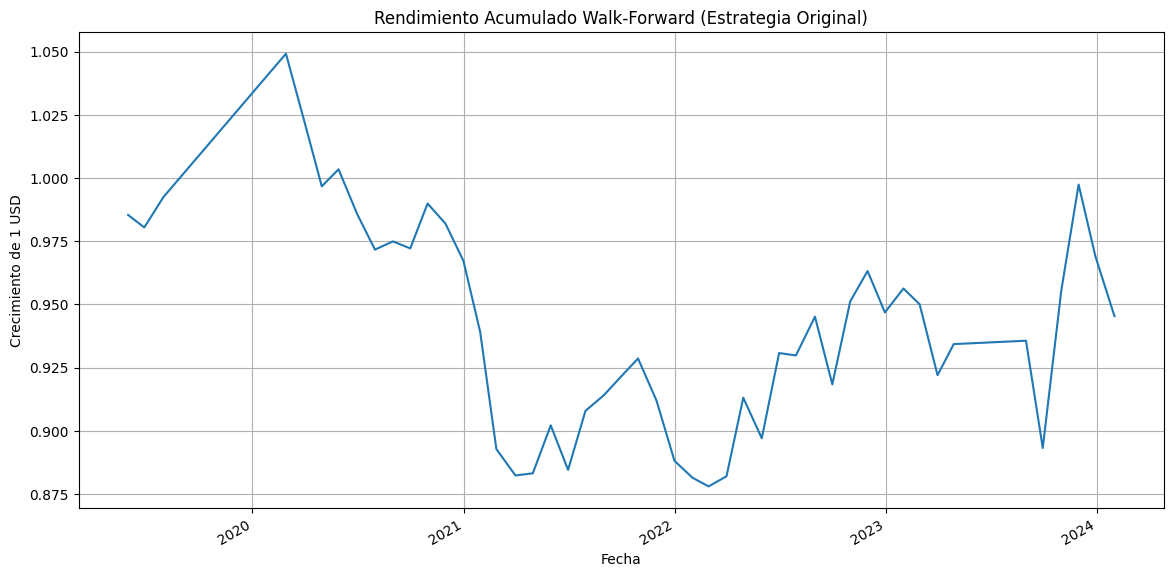


--- 2. Resultados del Backtest con Neutralización por Sector ---
Retorno Mensual Promedio del Spread (Neutralizado): -0.1014%
Sharpe Ratio Anualizado de la Estrategia (Neutralizada): -0.17


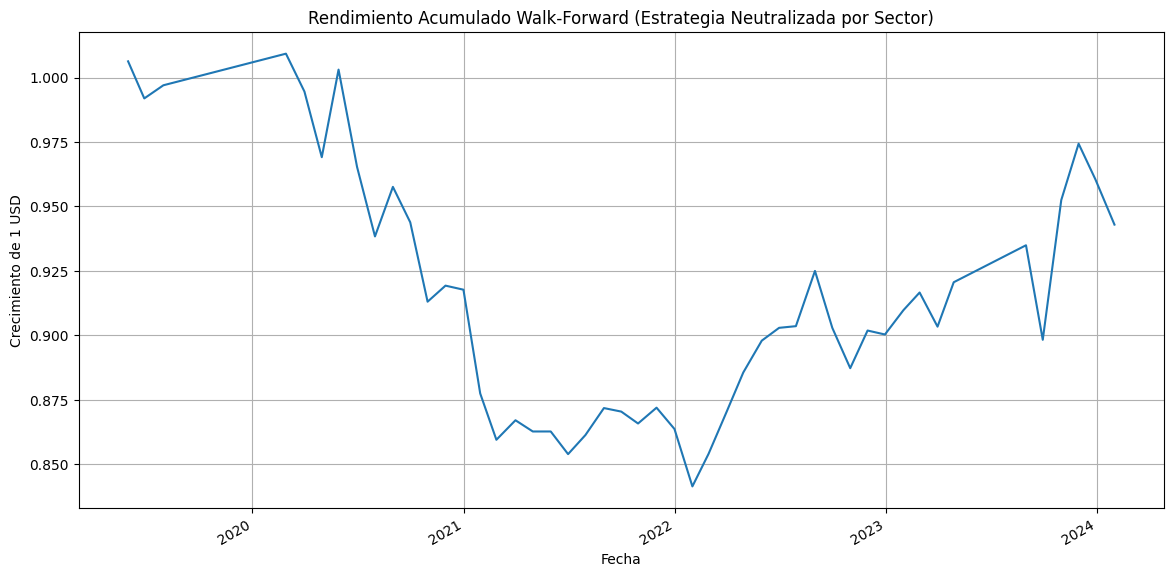


--- 3. Análisis de Turnover de la Cartera (Original) ---
Turnover Mensual Promedio (Cartera Long): 55.50%


In [10]:
# ================================================================================
# BLOQUE 6: BACKTESTING WALK-FORWARD ROBUSTO
# ================================================================================
from dateutil.relativedelta import relativedelta

print("\nIniciando Backtesting con Estrategia Walk-Forward...")

# --- 6.1: Configuración del Backtest Walk-Forward ---

# Fecha de inicio para el primer período de PRUEBA.
START_DATE_BACKTEST = pd.to_datetime('2019-01-01') 

# Duración de cada período de entrenamiento (en meses).
TRAIN_WINDOW_MONTHS = 4 * 12 

# Duración de cada período de prueba (out-of-sample).
TEST_WINDOW_MONTHS = 6

# --- 6.2: Bucle Principal de Walk-Forward ---

all_results_df = []
current_test_start_date = START_DATE_BACKTEST

while True:
    # Definir las fechas para el período actual
    train_end_date = current_test_start_date - pd.DateOffset(days=1)
    train_start_date = train_end_date - relativedelta(months=TRAIN_WINDOW_MONTHS)
    test_end_date = current_test_start_date + relativedelta(months=TEST_WINDOW_MONTHS) - pd.DateOffset(days=1)

    if current_test_start_date > df_model['Fecha'].max():
        print("\nFin del backtest: se han procesado todos los datos disponibles.")
        break

    print(f"\n--- Procesando Período ---")
    print(f"  Entrenamiento: {train_start_date.date()} a {train_end_date.date()}")
    print(f"  Prueba (OOS):  {current_test_start_date.date()} a {test_end_date.date()}")

    # Filtrar los datos para este fold
    train_df = df_model[(df_model['Fecha'] >= train_start_date) & (df_model['Fecha'] <= train_end_date)]
    test_df = df_model[(df_model['Fecha'] >= current_test_start_date) & (df_model['Fecha'] <= test_end_date)]

    if train_df.empty or test_df.empty:
        print("  ADVERTENCIA: Datos insuficientes para este período. Saltando.")
        current_test_start_date += relativedelta(months=TEST_WINDOW_MONTHS)
        continue

    X_train, y_train = train_df[predictor_cols_final], train_df[TARGET_COL]
    X_test, y_test = test_df[predictor_cols_final], test_df[TARGET_COL]

    model = XGBRegressor(n_estimators=1500,
                     learning_rate=0.03,
                     max_depth=3,
                     subsample=0.8,
                     colsample_bytree=0.6,
                     reg_lambda=1.0,
                     random_state=42,
                     n_jobs=-1)
    # La regularización se encarga de prevenir el overfitting.
     
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # --- INICIO DE LA CORRECCIÓN ---
    # Guardar los resultados de este período usando el nombre correcto de la columna objetivo (TARGET_COL)
    period_results = test_df[['Fecha', 'Empresa', 'Sector', TARGET_COL]].copy()
    
    # Renombrar la columna objetivo a 'retorno_real' para un análisis consistente
    period_results.rename(columns={TARGET_COL: 'retorno_real'}, inplace=True)
    
    # Añadir las predicciones
    period_results['prediccion_retorno'] = y_pred
    all_results_df.append(period_results)
    # --- FIN DE LA CORRECCIÓN ---

    current_test_start_date += relativedelta(months=TEST_WINDOW_MONTHS)

# --- 6.3: Consolidación y Análisis de Resultados del Backtest Completo ---

if not all_results_df:
    print("\nNo se generaron resultados. El backtest no se pudo completar.")
else:
    backtest_results_df = pd.concat(all_results_df, ignore_index=True)
    print(f"\nBacktest completado. Se generaron predicciones para {len(backtest_results_df)} observaciones.")

    # --- ANÁLISIS 1: BACKTEST ORIGINAL (SIN NEUTRALIZAR) ---
    print("\n--- 1. Resultados del Backtest de Cartera (Original) ---")
    backtest_results_df['quintil_pred'] = backtest_results_df.groupby('Fecha')['prediccion_retorno'].transform(
        lambda x: pd.qcut(x, 5, labels=False, duplicates='drop')
    )
    retornos_por_quintil = backtest_results_df.groupby(['Fecha', 'quintil_pred'])['retorno_real'].mean().unstack()

    if 4 in retornos_por_quintil.columns and 0 in retornos_por_quintil.columns:
        retornos_por_quintil['long_short_spread'] = retornos_por_quintil[4] - retornos_por_quintil[0]
        retornos_por_quintil.dropna(subset=['long_short_spread'], inplace=True)

        retorno_promedio = retornos_por_quintil['long_short_spread'].mean()
        volatilidad = retornos_por_quintil['long_short_spread'].std()
        sharpe_ratio = (retorno_promedio / volatilidad) * np.sqrt(12) if volatilidad > 0 else 0
        
        print(f"Período Total del Backtest: {backtest_results_df['Fecha'].min().date()} a {backtest_results_df['Fecha'].max().date()}")
        print(f"Retorno Mensual Promedio del Spread (Q5-Q1): {retorno_promedio:.4%}")
        print(f"Sharpe Ratio Anualizado de la Estrategia: {sharpe_ratio:.2f}")
        
        (1 + retornos_por_quintil['long_short_spread']).cumprod().plot(
            figsize=(14, 7), title='Rendimiento Acumulado Walk-Forward (Estrategia Original)', grid=True
        )
        plt.ylabel("Crecimiento de 1 USD")
        plt.show()
    else:
        print("\nNo se pudieron calcular los retornos de la cartera original (quintiles faltantes).")

    # --- ANÁLISIS 2: BACKTEST CON NEUTRALIZACIÓN POR SECTOR ---
    print("\n--- 2. Resultados del Backtest con Neutralización por Sector ---")
    backtest_results_df['pred_neutral'] = backtest_results_df.groupby(['Fecha', 'Sector'])['prediccion_retorno'].transform(
        lambda x: (x - x.mean()) / x.std() if x.std() > 0 else 0
    )
    backtest_results_df.dropna(subset=['pred_neutral'], inplace=True)
    backtest_results_df['quintil_pred_neutral'] = backtest_results_df.groupby('Fecha')['pred_neutral'].transform(
        lambda x: pd.qcut(x, 5, labels=False, duplicates='drop')
    )
    retornos_neutral = backtest_results_df.groupby(['Fecha', 'quintil_pred_neutral'])['retorno_real'].mean().unstack()

    if 4 in retornos_neutral.columns and 0 in retornos_neutral.columns:
        retornos_neutral['long_short_spread'] = retornos_neutral[4] - retornos_neutral[0]
        retornos_neutral.dropna(subset=['long_short_spread'], inplace=True)

        retorno_promedio_neutral = retornos_neutral['long_short_spread'].mean()
        volatilidad_neutral = retornos_neutral['long_short_spread'].std()
        sharpe_ratio_neutral = (retorno_promedio_neutral / volatilidad_neutral) * np.sqrt(12) if volatilidad_neutral > 0 else 0
        
        print(f"Retorno Mensual Promedio del Spread (Neutralizado): {retorno_promedio_neutral:.4%}")
        print(f"Sharpe Ratio Anualizado de la Estrategia (Neutralizada): {sharpe_ratio_neutral:.2f}")
        
        (1 + retornos_neutral['long_short_spread']).cumprod().plot(
            figsize=(14, 7), title='Rendimiento Acumulado Walk-Forward (Estrategia Neutralizada por Sector)', grid=True
        )
        plt.ylabel("Crecimiento de 1 USD")
        plt.show()
    else:
        print("\nNo se pudieron calcular los retornos de la cartera neutralizada.")

    # --- ANÁLISIS 3: CÁLCULO DE TURNOVER ---
    print("\n--- 3. Análisis de Turnover de la Cartera (Original) ---")
    long_portfolio = backtest_results_df[backtest_results_df['quintil_pred'] == 4]
    dates = sorted(long_portfolio['Fecha'].unique())
    
    turnovers = []
    if len(dates) > 1:
        for i in range(1, len(dates)):
            prev_long_stocks = set(long_portfolio[long_portfolio['Fecha'] == dates[i-1]]['Empresa'])
            curr_long_stocks = set(long_portfolio[long_portfolio['Fecha'] == dates[i]]['Empresa'])
            
            if len(prev_long_stocks) > 0:
                sold_stocks = len(prev_long_stocks - curr_long_stocks)
                monthly_turnover = sold_stocks / len(prev_long_stocks)
                turnovers.append(monthly_turnover)

    if turnovers:
        avg_turnover = np.mean(turnovers)
        print(f"Turnover Mensual Promedio (Cartera Long): {avg_turnover:.2%}")
    else:
        print("No se pudo calcular el turnover.")


EJECUTANDO BACKTEST: Ventana de Entrenamiento = 48 meses, Ventana de Prueba = 6 meses

EJECUTANDO BACKTEST: Ventana de Entrenamiento = 36 meses, Ventana de Prueba = 6 meses

EJECUTANDO BACKTEST: Ventana de Entrenamiento = 24 meses, Ventana de Prueba = 6 meses

EJECUTANDO BACKTEST: Ventana de Entrenamiento = 48 meses, Ventana de Prueba = 3 meses

EJECUTANDO BACKTEST: Ventana de Entrenamiento = 48 meses, Ventana de Prueba = 12 meses


RESUMEN DEL ANÁLISIS DE SENSIBILIDAD
   train_window  test_window  sharpe_original  sharpe_neutral  turnover
0            48            6           -0.120          -0.170     0.555
1            36            6           -0.751          -0.490     0.574
2            24            6           -0.009           0.040     0.569
3            48            3           -0.560          -0.801     0.597
4            48           12           -0.635          -0.678     0.535


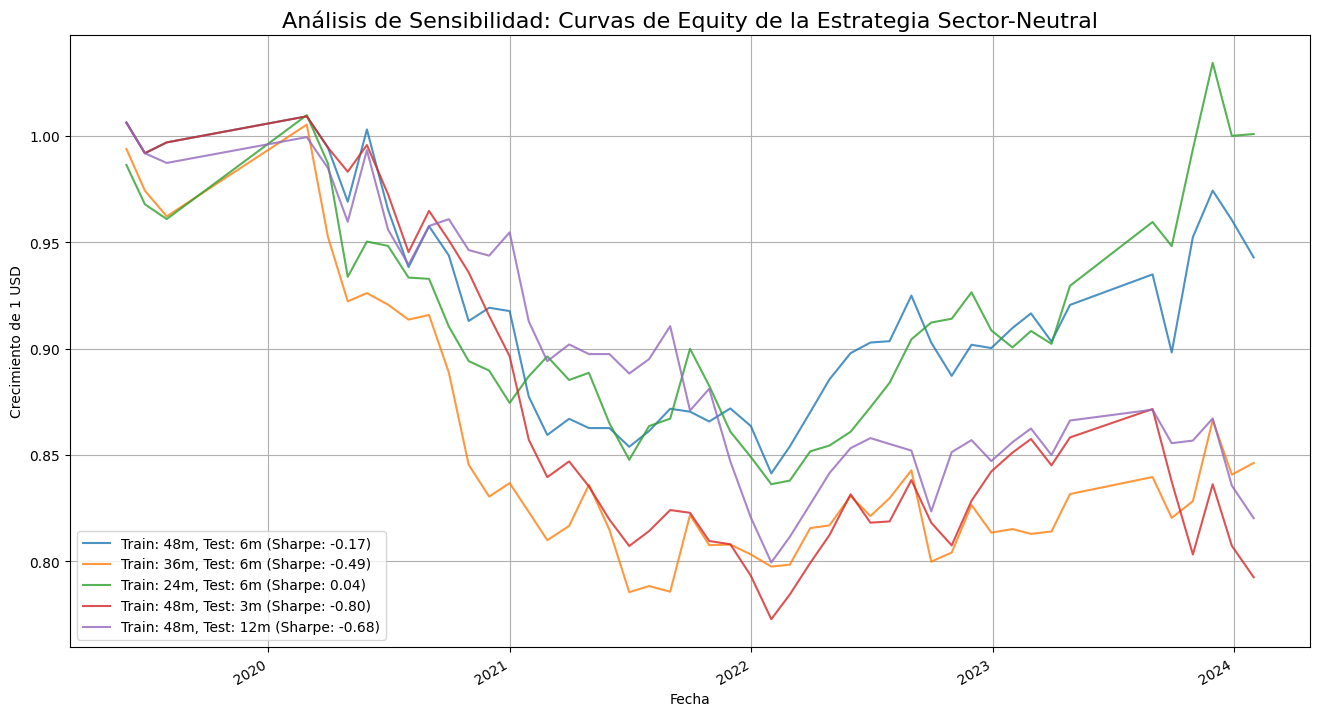

In [11]:
# ================================================================================
# BLOQUE 7: ANÁLISIS DE SENSIBILIDAD AUTOMATIZADO CON WALK-FORWARD
# ================================================================================
from dateutil.relativedelta import relativedelta
import matplotlib.pyplot as plt

# --- 6.1: Función de Backtesting Walk-Forward ---
# Encapsulamos toda la lógica del backtest en una función reutilizable.

def run_walk_forward_backtest(df_model, predictor_cols_final, target_col, 
                              train_window_months, test_window_months, 
                              start_date_backtest=pd.to_datetime('2019-01-01')):
    """
    Ejecuta un backtest walk-forward completo con una configuración de ventanas específica.
    
    Args:
        df_model (pd.DataFrame): El DataFrame completo con features y target.
        predictor_cols_final (list): Lista de nombres de las columnas predictoras.
        target_col (str): Nombre de la columna objetivo.
        train_window_months (int): Duración de la ventana de entrenamiento en meses.
        test_window_months (int): Duración de la ventana de prueba en meses.
        start_date_backtest (pd.Timestamp): Fecha de inicio del primer período de prueba.
        
    Returns:
        dict: Un diccionario con las métricas clave y el DataFrame de resultados.
    """
    print(f"\n{'='*80}")
    print(f"EJECUTANDO BACKTEST: Ventana de Entrenamiento = {train_window_months} meses, Ventana de Prueba = {test_window_months} meses")
    print(f"{'='*80}")

    all_results_df = []
    current_test_start_date = start_date_backtest

    while current_test_start_date <= df_model['Fecha'].max():
        train_end_date = current_test_start_date - pd.DateOffset(days=1)
        train_start_date = train_end_date - relativedelta(months=train_window_months)
        test_end_date = current_test_start_date + relativedelta(months=test_window_months) - pd.DateOffset(days=1)

        # ... (Lógica del bucle walk-forward, sin cambios) ...
        train_df = df_model[(df_model['Fecha'] >= train_start_date) & (df_model['Fecha'] <= train_end_date)]
        test_df = df_model[(df_model['Fecha'] >= current_test_start_date) & (df_model['Fecha'] <= test_end_date)]

        if train_df.empty or test_df.empty:
            current_test_start_date += relativedelta(months=test_window_months)
            continue

        X_train, y_train = train_df[predictor_cols_final], train_df[target_col]
        X_test, y_test = test_df[predictor_cols_final], test_df[target_col]

        model = XGBRegressor(n_estimators=1500,
                     learning_rate=0.03,
                     max_depth=3,
                     subsample=0.8,
                     colsample_bytree=0.6,
                     reg_lambda=1.0,
                     random_state=42,
                     n_jobs=-1)

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        period_results = test_df[['Fecha', 'Empresa', 'Sector', target_col]].copy()
        period_results.rename(columns={target_col: 'retorno_real'}, inplace=True)
        period_results['prediccion_retorno'] = y_pred
        all_results_df.append(period_results)

        current_test_start_date += relativedelta(months=test_window_months)

    if not all_results_df:
        print("  -> No se generaron resultados para esta configuración.")
        return None

    backtest_results_df = pd.concat(all_results_df, ignore_index=True)
    
    # --- Análisis de resultados para esta configuración ---
    results = {
        'train_window': train_window_months,
        'test_window': test_window_months,
        'sharpe_original': None,
        'sharpe_neutral': None,
        'turnover': None,
        'equity_curve_original': None,
        'equity_curve_neutral': None
    }

    # Análisis Original
    backtest_results_df['quintil_pred'] = backtest_results_df.groupby('Fecha')['prediccion_retorno'].transform(lambda x: pd.qcut(x, 5, labels=False, duplicates='drop'))
    retornos_original = backtest_results_df.groupby(['Fecha', 'quintil_pred'])['retorno_real'].mean().unstack()
    if 4 in retornos_original.columns and 0 in retornos_original.columns:
        retornos_original['spread'] = retornos_original[4] - retornos_original[0]
        retornos_original.dropna(subset=['spread'], inplace=True)
        if not retornos_original.empty:
            vol = retornos_original['spread'].std()
            results['sharpe_original'] = (retornos_original['spread'].mean() / vol) * np.sqrt(12) if vol > 0 else 0
            results['equity_curve_original'] = (1 + retornos_original['spread']).cumprod()

    # Análisis Neutralizado
    backtest_results_df['pred_neutral'] = backtest_results_df.groupby(['Fecha', 'Sector'])['prediccion_retorno'].transform(lambda x: (x - x.mean()) / x.std() if x.std() > 0 else 0)
    backtest_results_df.dropna(subset=['pred_neutral'], inplace=True)
    backtest_results_df['quintil_neutral'] = backtest_results_df.groupby('Fecha')['pred_neutral'].transform(lambda x: pd.qcut(x, 5, labels=False, duplicates='drop'))
    retornos_neutral = backtest_results_df.groupby(['Fecha', 'quintil_neutral'])['retorno_real'].mean().unstack()
    if 4 in retornos_neutral.columns and 0 in retornos_neutral.columns:
        retornos_neutral['spread'] = retornos_neutral[4] - retornos_neutral[0]
        retornos_neutral.dropna(subset=['spread'], inplace=True)
        if not retornos_neutral.empty:
            vol = retornos_neutral['spread'].std()
            results['sharpe_neutral'] = (retornos_neutral['spread'].mean() / vol) * np.sqrt(12) if vol > 0 else 0
            results['equity_curve_neutral'] = (1 + retornos_neutral['spread']).cumprod()

    # Análisis de Turnover
    long_portfolio = backtest_results_df[backtest_results_df['quintil_pred'] == 4]
    dates = sorted(long_portfolio['Fecha'].unique())
    turnovers = []
    if len(dates) > 1:
        for i in range(1, len(dates)):
            prev_stocks = set(long_portfolio[long_portfolio['Fecha'] == dates[i-1]]['Empresa'])
            curr_stocks = set(long_portfolio[long_portfolio['Fecha'] == dates[i]]['Empresa'])
            if len(prev_stocks) > 0:
                turnovers.append(len(prev_stocks - curr_stocks) / len(prev_stocks))
    if turnovers:
        results['turnover'] = np.mean(turnovers)

    return results

# --- 6.2: Bucle de Ejecución del Análisis de Sensibilidad ---

# Define las configuraciones de ventanas que quieres probar
configurations = [
    {'train': 48, 'test': 6},  # Tu configuración original
    {'train': 36, 'test': 6},  # Ventana de entrenamiento más corta
    {'train': 24, 'test': 6},  # Ventana de entrenamiento muy corta
    {'train': 48, 'test': 3},  # Reentrenamiento más frecuente
    {'train': 48, 'test': 12}, # Reentrenamiento menos frecuente
]

all_run_results = []

for config in configurations:
    result = run_walk_forward_backtest(
        df_model=df_model,
        predictor_cols_final=predictor_cols_final,
        target_col=TARGET_COL,
        train_window_months=config['train'],
        test_window_months=config['test']
    )
    if result:
        all_run_results.append(result)

# --- 6.3: Resumen y Visualización de Resultados ---

print(f"\n\n{'='*80}")
print("RESUMEN DEL ANÁLISIS DE SENSIBILIDAD")
print(f"{'='*80}")

# Crear un DataFrame con los resultados para una fácil comparación
summary_df = pd.DataFrame(all_run_results)
summary_df = summary_df.drop(columns=['equity_curve_original', 'equity_curve_neutral']) # Quitar las series para ver la tabla
print(summary_df.round(3))


# Visualizar las curvas de equity de la estrategia NEUTRALIZADA (la que importa)
plt.figure(figsize=(16, 9))
for result in all_run_results:
    if result['equity_curve_neutral'] is not None:
        label = f"Train: {result['train_window']}m, Test: {result['test_window']}m (Sharpe: {result['sharpe_neutral']:.2f})"
        result['equity_curve_neutral'].plot(label=label, alpha=0.8)

plt.title('Análisis de Sensibilidad: Curvas de Equity de la Estrategia Sector-Neutral', fontsize=16)
plt.ylabel('Crecimiento de 1 USD')
plt.xlabel('Fecha')
plt.grid(True)
plt.legend()
plt.show()